<a href="https://colab.research.google.com/github/GUIVICFISHER/RiskNeutralKernel2026/blob/main/STOCK_ANALYZER_EXP_1_ALPACA_CONNECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Graphical Linear Analysis: Scatter Plot of Daily Percentage Changes

/tmp/ipykernel_677/800952646.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/800952646.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


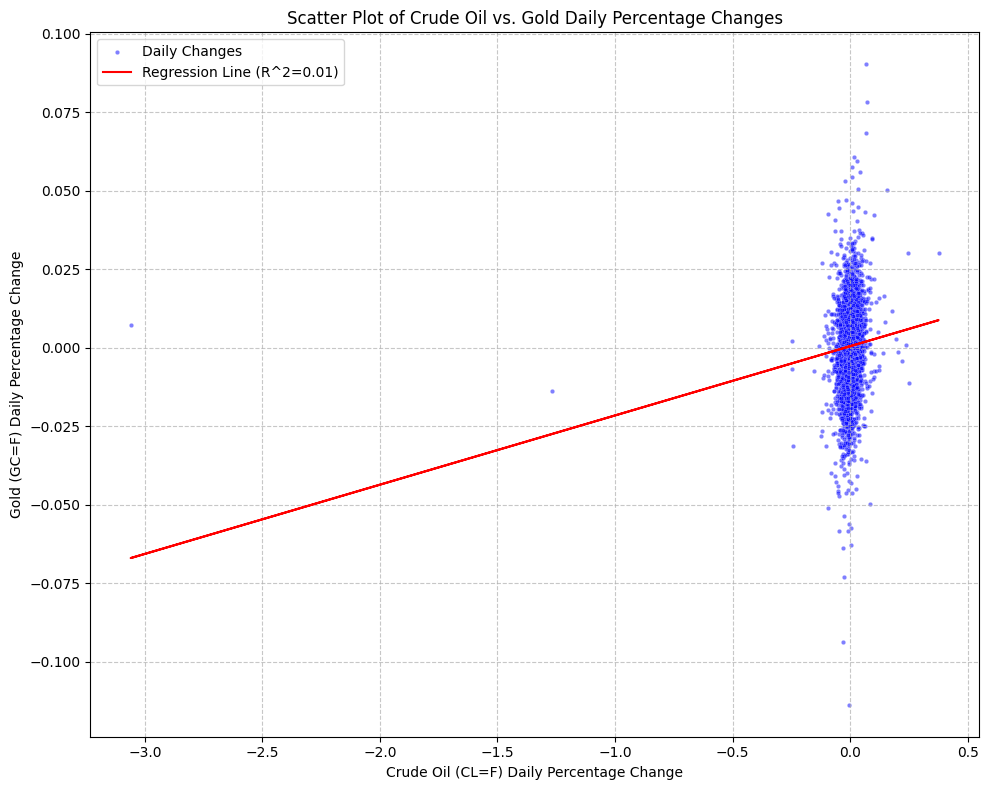

Linear Regression Results for Oil vs. Gold Daily Changes:
  Slope: 0.0220
  Intercept: 0.0005
  R-squared: 0.0093
  P-value: 0.0000


In [9]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Extract daily percentage changes for Oil and Gold, ensuring they are Series
oil_changes = price_changes['Oil_Close'].squeeze()
gold_changes = price_changes['Gold_Close'].squeeze()

# Drop any remaining NaNs in either series to ensure clean plotting
df_scatter = pd.DataFrame({
    'Oil_Daily_Change': oil_changes,
    'Gold_Daily_Change': gold_changes
}).dropna()

# Perform linear regression
lin_regress_results = linregress(df_scatter['Oil_Daily_Change'], df_scatter['Gold_Daily_Change'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Oil_Daily_Change',
    y='Gold_Daily_Change',
    data=df_scatter,
    alpha=0.5,
    s=10,
    color='blue',
    label='Daily Changes'
)

# Add the regression line
plt.plot(
    df_scatter['Oil_Daily_Change'],
    lin_regress_results.intercept + lin_regress_results.slope * df_scatter['Oil_Daily_Change'],
    color='red',
    label=f'Regression Line (R^2={lin_regress_results.rvalue**2:.2f})'
)

plt.title('Scatter Plot of Crude Oil vs. Gold Daily Percentage Changes')
plt.xlabel(f'Crude Oil ({oil_ticker}) Daily Percentage Change')
plt.ylabel(f'Gold ({gold_ticker}) Daily Percentage Change')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Linear Regression Results for Oil vs. Gold Daily Changes:")
print(f"  Slope: {lin_regress_results.slope:.4f}")
print(f"  Intercept: {lin_regress_results.intercept:.4f}")
print(f"  R-squared: {lin_regress_results.rvalue**2:.4f}")
print(f"  P-value: {lin_regress_results.pvalue:.4f}")

### Comprehensive Numerical Grid Output: Comparison of Econometric Measures for Oil and Gold

In [15]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import grangercausalitytests, coint, adfuller

# Define ticker symbols for Oil and Gold futures (needed for Granger and Cointegration)
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil and Gold (needed for Granger and Cointegration)
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()
combined_data.columns = ['Oil_Close', 'Gold_Close'] # Flatten MultiIndex and rename for consistency
price_changes = combined_data.pct_change().dropna()

# --- Re-run necessary analyses to ensure variables are defined ---

# Granger Causality Test (from 5e985854)
# Prepare the data for Granger Causality Test
df_granger = price_changes[['Oil_Close', 'Gold_Close']].copy()
granger_results_oil_gold = grangercausalitytests(df_granger[['Gold_Close', 'Oil_Close']], maxlag=[5, 20], verbose=False)
granger_results_gold_oil = grangercausalitytests(df_granger[['Oil_Close', 'Gold_Close']], maxlag=[5, 20], verbose=False)

# Cointegration Test (from 11776ce3)
series1_prices = combined_data['Oil_Close']
series2_prices = combined_data['Gold_Close']
coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

# ADF Test (from 3ea17950)
adf_oil = adfuller(price_changes['Oil_Close'].dropna())
adf_gold = adfuller(price_changes['Gold_Close'].dropna())


# --- Collect Results from Previous Analyses ---

# 1. Linear Regression (from abc14c11)
# Assumes lin_regress_results is available from abc14c11 execution
lin_regress_results_summary = {
    'Measure': 'Linear Regression (Oil vs. Gold Daily Changes)',
    'Description': 'Slope and R-squared of daily percentage changes',
    'Result 1': f"Slope: {lin_regress_results.slope:.4f}",
    'Result 2': f"R-squared: {lin_regress_results.rvalue**2:.4f}",
    'Conclusion': f"P-value: {lin_regress_results.pvalue:.4f} (Significant if < 0.05)"
}

# 2. ANOVA for Oil (from 3104e9d5)
# Assumes oil_anova_table is available from 3104e9d5 execution
oil_anova_conclusion = "Significant difference across years" if oil_anova_table['PR(>F)'].iloc[0] < 0.05 else "No significant difference across years"
anova_oil_summary = {
    'Measure': 'ANOVA (Oil Daily Changes by Year)',
    'Description': 'Tests if mean daily change differs by year',
    'Result 1': f"F-statistic: {oil_anova_table['F'].iloc[0]:.4f}",
    'Result 2': f"P-value: {oil_anova_table['PR(>F)'].iloc[0]:.4f}",
    'Conclusion': oil_anova_conclusion
}

# 3. ANOVA for Gold (from 3104e9d5)
# Assumes gold_anova_table is available from 3104e9d5 execution
gold_anova_conclusion = "Significant difference across years" if gold_anova_table['PR(>F)'].iloc[0] < 0.05 else "No significant difference across years"
anova_gold_summary = {
    'Measure': 'ANOVA (Gold Daily Changes by Year)',
    'Description': 'Tests if mean daily change differs by year',
    'Result 1': f"F-statistic: {gold_anova_table['F'].iloc[0]:.4f}",
    'Result 2': f"P-value: {gold_anova_table['PR(>F)'].iloc[0]:.4f}",
    'Conclusion': gold_anova_conclusion
}

# 4. MANOVA (from 2938a499)
# Assumes manova_results is available from 2938a499 execution
manova_summary_str = str(manova_results.mv_test().summary())
manova_p_value_line = [line for line in manova_summary_str.split('\n') if "Wilks' lambda" in line and 'C(Year)' in line]
manova_p_value = float(manova_p_value_line[0].split()[-1]) if manova_p_value_line else None

manova_conclusion = "Significant difference in combined mean vector across years" if manova_p_value and manova_p_value < 0.05 else "No significant difference in combined mean vector across years"
manova_summary = {
    'Measure': 'MANOVA (Oil & Gold Daily Changes by Year)',
    'Description': 'Tests if combined mean vector differs by year',
    'Result 1': f"Wilk's Lambda C(Year) P-value: {manova_p_value:.4f}" if manova_p_value is not None else "Wilk's Lambda C(Year) P-value: N/A",
    'Result 2': 'N/A',
    'Conclusion': manova_conclusion
}

# 5. Granger Causality (re-executed above)
granger_oil_gold_5_p = granger_results_oil_gold[5][0]['ssr_ftest'][1]
granger_gold_oil_5_p = granger_results_gold_oil[5][0]['ssr_ftest'][1]
granger_oil_gold_20_p = granger_results_oil_gold[20][0]['ssr_ftest'][1]
granger_gold_oil_20_p = granger_results_gold_oil[20][0]['ssr_ftest'][1]

granger_summary = {
    'Measure': 'Granger Causality Test',
    'Description': 'Does one series help predict the other?',
    'Result 1': f"Oil -> Gold (Lag 5) P-value: {granger_oil_gold_5_p:.4f} ({'Yes' if granger_oil_gold_5_p < 0.05 else 'No'})",
    'Result 2': f"Gold -> Oil (Lag 5) P-value: {granger_gold_oil_5_p:.4f} ({'Yes' if granger_gold_oil_5_p < 0.05 else 'No'})",
    'Conclusion': f"Oil -> Gold (Lag 20) P-value: {granger_oil_gold_20_p:.4f} ({'Yes' if granger_oil_gold_20_p < 0.05 else 'No'}); Gold -> Oil (Lag 20) P-value: {granger_gold_oil_20_p:.4f} ({'Yes' if granger_gold_oil_20_p < 0.05 else 'No'})"
}

# 6. Cointegration Test (re-executed above)
cointegration_summary = {
    'Measure': 'Cointegration Test (Engle-Granger)',
    'Description': 'Tests for long-term equilibrium relationship',
    'Result 1': f"Test Statistic: {coint_t:.3f}",
    'Result 2': f"P-value: {coint_p_value:.3f}",
    'Conclusion': f"{'Likely cointegrated' if coint_p_value < 0.05 else 'Likely NOT cointegrated'} (Critical Values: 1%:{coint_critical_values[0]:.3f}, 5%:{coint_critical_values[1]:.3f})"
}

# 7. ADF Test (Stationarity) (re-executed above)
adf_oil_summary = {
    'Measure': 'ADF Test (Oil Daily Changes)',
    'Description': 'Tests for stationarity',
    'Result 1': f"ADF Statistic: {adf_oil[0]:.4f}",
    'Result 2': f"P-value: {adf_oil[1]:.4f}",
    'Conclusion': f"{'Stationary' if adf_oil[1] <= 0.05 else 'Non-stationary'}"
}
adf_gold_summary = {
    'Measure': 'ADF Test (Gold Daily Changes)',
    'Description': 'Tests for stationarity',
    'Result 1': f"ADF Statistic: {adf_gold[0]:.4f}",
    'Result 2': f"P-value: {adf_gold[1]:.4f}",
    'Conclusion': f"{'Stationary' if adf_gold[1] <= 0.05 else 'Non-stationary'}"
}

# Combine all summaries into a DataFrame
summary_df = pd.DataFrame([
    lin_regress_results_summary,
    anova_oil_summary,
    anova_gold_summary,
    manova_summary,
    granger_summary,
    cointegration_summary,
    adf_oil_summary,
    adf_gold_summary
])

display(summary_df)

print("\n--- Interpretation Guide ---")
print("For P-values: A value less than 0.05 generally indicates statistical significance.")
print("For Granger Causality and Cointegration: Conclusions are based on the p-value relative to chosen significance levels (e.g., 0.05).")
print("For ADF Test: A p-value <= 0.05 suggests the series is stationary.")

/tmp/ipykernel_677/2562012428.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2562012428.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,Measure,Description,Result 1,Result 2,Conclusion
0,Linear Regression (Oil vs. Gold Daily Changes),Slope and R-squared of daily percentage changes,Slope: 0.0220,R-squared: 0.0093,P-value: 0.0000 (Significant if < 0.05)
1,ANOVA (Oil Daily Changes by Year),Tests if mean daily change differs by year,F-statistic: 1.0748,P-value: 0.3616,No significant difference across years
2,ANOVA (Gold Daily Changes by Year),Tests if mean daily change differs by year,F-statistic: 0.7633,P-value: 0.7985,No significant difference across years
3,MANOVA (Oil & Gold Daily Changes by Year),Tests if combined mean vector differs by year,Wilk's Lambda C(Year) P-value: N/A,N/A,No significant difference in combined mean vec...
4,Granger Causality Test,Does one series help predict the other?,Oil -> Gold (Lag 5) P-value: 0.0612 (No),Gold -> Oil (Lag 5) P-value: 0.0313 (Yes),Oil -> Gold (Lag 20) P-value: 0.0959 (No); Gol...
5,Cointegration Test (Engle-Granger),Tests for long-term equilibrium relationship,Test Statistic: -3.215,P-value: 0.067,Likely NOT cointegrated (Critical Values: 1%:-...
6,ADF Test (Oil Daily Changes),Tests for stationarity,ADF Statistic: -14.7778,P-value: 0.0000,Stationary
7,ADF Test (Gold Daily Changes),Tests for stationarity,ADF Statistic: -31.8773,P-value: 0.0000,Stationary



--- Interpretation Guide ---
For P-values: A value less than 0.05 generally indicates statistical significance.
For Granger Causality and Cointegration: Conclusions are based on the p-value relative to chosen significance levels (e.g., 0.05).
For ADF Test: A p-value <= 0.05 suggests the series is stationary.


### ANOVA and MANOVA Analysis (Yearly Comparison of Mean Returns)

To apply ANOVA (Analysis of Variance) and MANOVA (Multivariate Analysis of Variance), we need to define groups. A natural way to do this with time series data is to group by a time unit, such as year. We will examine if the *mean daily percentage changes* of Oil and Gold differ significantly across different years.

In [10]:
import yfinance as yf
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access and compatibility with statsmodels formulas
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Add a 'Year' column to the price_changes DataFrame
price_changes['Year'] = price_changes.index.year

print("--- ANOVA for Crude Oil Daily Percentage Changes (by Year) ---")
# ANOVA for Oil
oil_model = ols('Oil_Close ~ C(Year)', data=price_changes).fit()
oil_anova_table = sm.stats.anova_lm(oil_model, typ=2)
display(oil_anova_table)

if oil_anova_table['PR(>F)'][0] < 0.05:
    print(f"Conclusion: There is a statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value < 0.05).")
else:
    print(f"Conclusion: There is no statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value >= 0.05).")

print("\n--- ANOVA for Gold Daily Percentage Changes (by Year) ---")
# ANOVA for Gold
gold_model = ols('Gold_Close ~ C(Year)', data=price_changes).fit()
gold_anova_table = sm.stats.anova_lm(gold_model, typ=2)
display(gold_anova_table)

if gold_anova_table['PR(>F)'][0] < 0.05:
    print(f"Conclusion: There is a statistically significant difference in the mean daily percentage changes of Gold across different years (p-value < 0.05).")
else:
    print(f"Conclusion: There is no statistically significant difference in the mean daily percentage changes of Gold across different years (p-value >= 0.05).")

/tmp/ipykernel_677/2425439699.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2425439699.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed

--- ANOVA for Crude Oil Daily Percentage Changes (by Year) ---


,sum_sq,df,F,PR(>F)
C(Year),0.066744,26.0,1.074787,0.361622
Residual,15.243105,6382.0,NaN,NaN


Conclusion: There is no statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value >= 0.05).

--- ANOVA for Gold Daily Percentage Changes (by Year) ---


/tmp/ipykernel_677/2425439699.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if oil_anova_table['PR(>F)'][0] < 0.05:


,sum_sq,df,F,PR(>F)
C(Year),0.002476,26.0,0.763268,0.798546
Residual,0.796175,6382.0,NaN,NaN


Conclusion: There is no statistically significant difference in the mean daily percentage changes of Gold across different years (p-value >= 0.05).


/tmp/ipykernel_677/2425439699.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gold_anova_table['PR(>F)'][0] < 0.05:


### MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year)

MANOVA extends ANOVA to situations with multiple dependent variables. Here, our dependent variables are the daily percentage changes of Oil and Gold. We'll test if the *vector of mean daily percentage changes* for Oil and Gold differs across years.

In [11]:
import yfinance as yf
import pandas as pd
from statsmodels.multivariate.manova import MANOVA

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access and compatibility with statsmodels formulas
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# For MANOVA, we need the dependent variables as a matrix and the independent variable (Year) as a factor.
# Ensure all years have enough observations. Let's filter out years with very few data points if any.

# Prepare data for MANOVA
# Add 'Year' column if not already present from ANOVA
if 'Year' not in price_changes.columns:
    price_changes['Year'] = price_changes.index.year

# Convert Year to categorical type for MANOVA
price_changes_manova = price_changes.copy()
price_changes_manova['Year'] = price_changes_manova['Year'].astype('category')

# Define dependent and independent variables
dependent_vars = price_changes_manova[['Oil_Close', 'Gold_Close']]
independent_var = price_changes_manova['Year']

# Construct the MANOVA formula string
formula = 'Oil_Close + Gold_Close ~ C(Year)'

# Perform MANOVA
# Note: MANOVA requires a balanced design for some tests, or at least enough observations per group.
# The default `MANOVA` class in statsmodels uses a generalized linear model approach.

print("--- MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year) ---")
manova_results = MANOVA.from_formula(formula, data=price_changes_manova)

# Display the Wilk's Lambda test results, which is common for MANOVA
print(manova_results.mv_test().summary())

# Interpretation guidance based on common MANOVA output structure
# Look for the 'P-value' associated with 'C(Year)' for the overall test.
# The 'PR(>F)' column in Wilk's Lambda output indicates the p-value.
# If this p-value is less than 0.05, there's a significant difference in the combined mean vector.

# Extracting p-value for C(Year) from Wilk's Lambda (assuming default output structure)
# This part can be tricky as summary() output is text. A more robust way might be needed for automation.
# For now, we will inspect the output manually.
print("\nInterpretation: In the table above, look at the row for 'C(Year)' and the 'PR(>F)' column under 'Wilks' lambda'.")
print("If this p-value is less than 0.05, it suggests a statistically significant difference in the combined mean daily percentage changes of Oil and Gold across different years.")

/tmp/ipykernel_677/2513944431.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2513944431.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


--- MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year) ---
                   Multivariate linear model
                                                                
----------------------------------------------------------------
         Intercept        Value  Num DF   Den DF  F Value Pr > F
----------------------------------------------------------------
            Wilks' lambda 1.0000 2.0000 6381.0000  0.0821 0.9211
           Pillai's trace 0.0000 2.0000 6381.0000  0.0821 0.9211
   Hotelling-Lawley trace 0.0000 2.0000 6381.0000  0.0821 0.9211
      Roy's greatest root 0.0000 2.0000 6381.0000  0.0821 0.9211
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
        C(Year)         Value   Num DF   Den DF   F Value Pr > F
----------------------------------------------------------------
          Wilks' lambda 0.9925 52.000

### Moving Averages for Oil and Gold Prices

To understand the underlying price trends, we can calculate and visualize the moving average of both Oil and Gold prices. A moving average smooths out price fluctuations over a specified period, making it easier to identify trends.

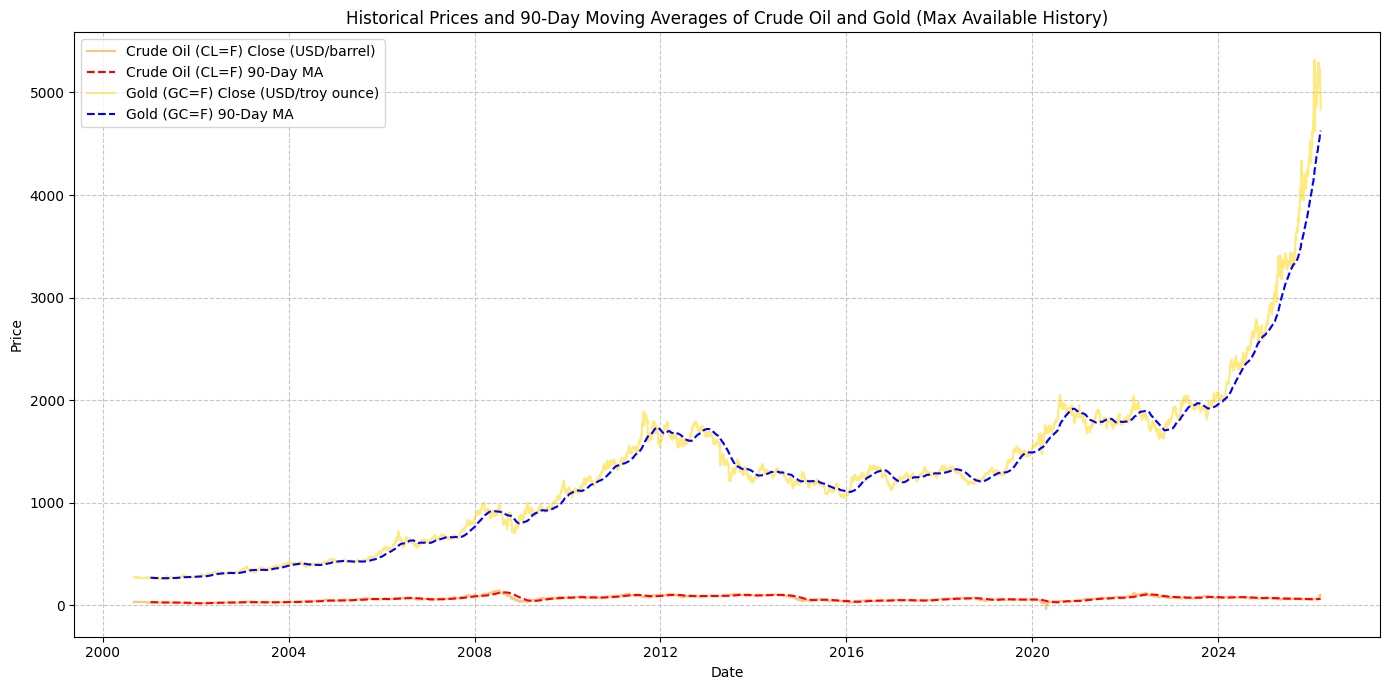

Displaying last few rows of combined_data with 90-day Moving Averages:


Price,CL=F_Close,GC=F_Close,CL=F_MA90,GC=F_MA90
Ticker,CL=F,GC=F,,
Date,,,,
2026-03-12,95.730003,5115.799805,62.764889,4583.893316
2026-03-13,98.709999,5052.500000,63.184111,4595.785539
2026-03-16,93.500000,4994.000000,63.544667,4606.826649
2026-03-17,96.209999,5001.000000,63.940778,4618.529983
2026-03-18,98.650002,4829.899902,64.374667,4627.969982


In [ ]:
# Define a window for the moving average (e.g., 90 days for a quarter)
window = 90

# Calculate the 90-day moving average for Oil and Gold prices
combined_data[f'{oil_ticker}_MA{window}'] = combined_data[f'{oil_ticker}_Close'].rolling(window=window).mean()
combined_data[f'{gold_ticker}_MA{window}'] = combined_data[f'{gold_ticker}_Close'].rolling(window=window).mean()

# Plotting the original prices and their moving averages
plt.figure(figsize=(14, 7))

plt.plot(combined_data.index, combined_data[f'{oil_ticker}_Close'], label=f'Crude Oil (CL=F) Close (USD/barrel)', color='darkorange', alpha=0.5)
plt.plot(combined_data.index, combined_data[f'{oil_ticker}_MA{window}'], label=f'Crude Oil (CL=F) {window}-Day MA', color='red', linestyle='--')

plt.plot(combined_data.index, combined_data[f'{gold_ticker}_Close'], label=f'Gold (GC=F) Close (USD/troy ounce)', color='gold', alpha=0.5)
plt.plot(combined_data.index, combined_data[f'{gold_ticker}_MA{window}'], label=f'Gold (GC=F) {window}-Day MA', color='blue', linestyle='--')

plt.title(f'Historical Prices and {window}-Day Moving Averages of Crude Oil and Gold (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few rows of combined_data with {window}-day Moving Averages:")
display(combined_data.tail())

### Moving Correlation between Oil and Gold

To understand how the relationship (correlation) between Oil and Gold changes over time, we can calculate a rolling (moving) correlation. This helps identify periods where their movements were more or less synchronized.

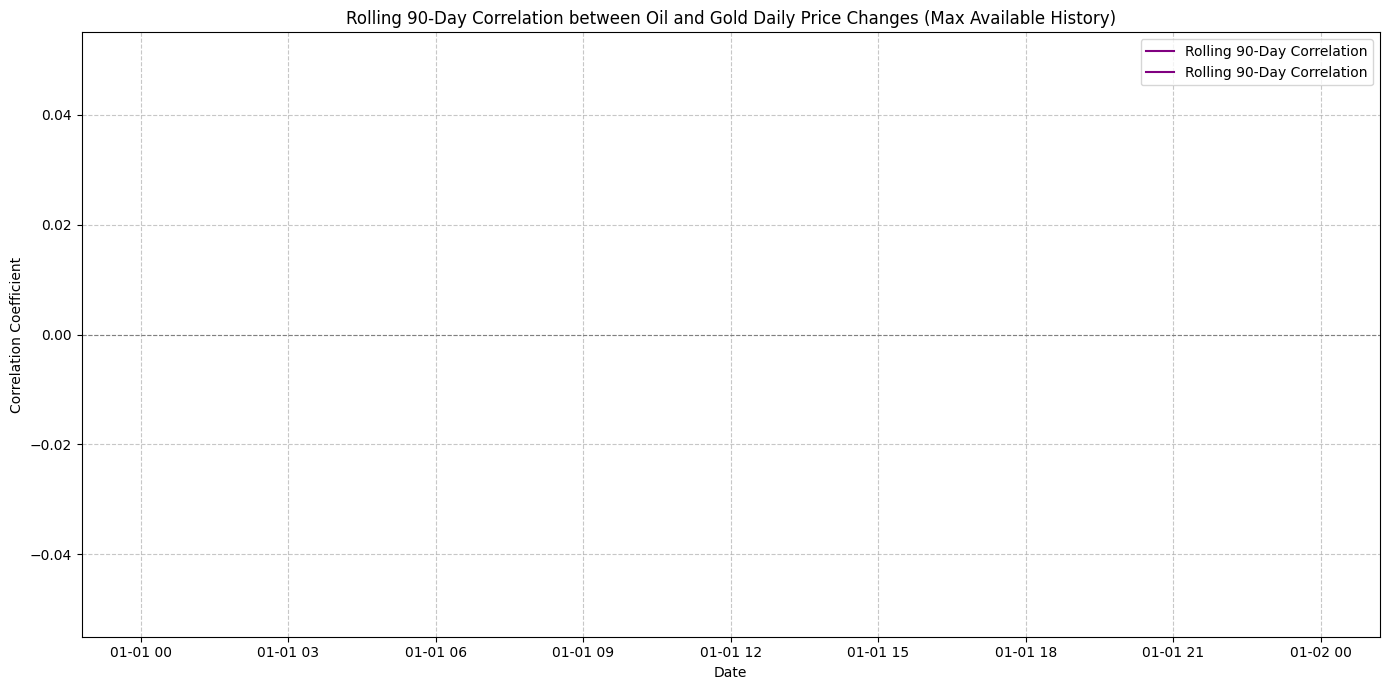

Displaying last few values of 90-day Rolling Correlation:


Ticker,CL=F,GC=F
Date,,
2026-03-12,NaN,NaN
2026-03-13,NaN,NaN
2026-03-16,NaN,NaN
2026-03-17,NaN,NaN
2026-03-18,NaN,NaN


In [ ]:
# Define a window for the moving correlation (consistent with MA, e.g., 90 days)
window = 90

# Calculate the 90-day rolling correlation between Oil and Gold daily percentage changes
moving_correlation = price_changes[f'{oil_ticker}_Close'].rolling(window=window).corr(price_changes[f'{gold_ticker}_Close'])

# Plotting the moving correlation
plt.figure(figsize=(14, 7))
plt.plot(moving_correlation.index, moving_correlation, label=f'Rolling {window}-Day Correlation', color='purple')

plt.title(f'Rolling {window}-Day Correlation between Oil and Gold Daily Price Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few values of {window}-day Rolling Correlation:")
display(moving_correlation.tail())

### Explanation of the Code and Underlying Math

#### 1. Obtaining Gold and Oil Tickers and Data

The code uses the `yfinance` library to fetch historical stock data. Here's a breakdown:

*   **`import yfinance as yf`**: Imports the `yfinance` library, commonly aliased as `yf`.
*   **`oil_ticker = 'CL=F'`** and **`gold_ticker = 'GC=F'`**: These are the ticker symbols used by Yahoo Finance for Crude Oil Futures (`CL=F`) and Gold Futures (`GC=F`).
*   **`yf.download(ticker, period=period)`**: This function is the core of data retrieval. It downloads historical data for a given `ticker` over a specified `period` (e.g., '5y' for 5 years).
*   **`oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})`**: After downloading, the data contains columns like 'Open', 'High', 'Low', 'Close', 'Adj Close', and 'Volume'. We are only interested in the 'Close' price, so we select it and then rename the column to make it unique and descriptive (e.g., 'CL=F_Close').
*   **`combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()`**: The individual Oil and Gold dataframes are merged side-by-side (`axis=1`) based on their common date index. `.dropna()` is then used to remove any rows where either Oil or Gold data might be missing, ensuring a clean dataset for correlation analysis.

#### 2. Obtaining Gold and Oil Correlation

Correlation measures the statistical relationship between two variables. Here's how it's calculated:

*   **`price_changes = combined_data.pct_change().dropna()`**: To calculate correlation between assets, it's common practice to use *percentage changes* (returns) rather than absolute prices. This is because absolute prices can diverge over time, making correlation misleading. `pct_change()` calculates the daily percentage change for each series (Oil and Gold closing prices). The first row will be `NaN` as there's no prior day to compare with, so `.dropna()` removes it.

    **Algebraic Expression for Percentage Change (Return):**
    The daily percentage change (or return) for an asset `P` at time `t` is calculated as:

    $$ R_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100 $$

    Where:
    *   `P_t` is the closing price on the current day.
    *   `P_{t-1}` is the closing price on the previous day.

*   **`correlation_matrix = price_changes.corr()`**: The `.corr()` method on a DataFrame calculates the Pearson correlation coefficient between all pairs of columns. In our case, it computes the correlation between the daily percentage changes of Oil and Gold.

    **Algebraic Expression for Pearson Correlation Coefficient:**
    The Pearson correlation coefficient (r) between two variables, X (Oil's daily changes) and Y (Gold's daily changes), is calculated as:

    $$ r = \frac{n(\sum xy) - (\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $$

    Where:
    *   `n` is the number of data points (days).
    *   `Σxy` is the sum of the products of the daily percentage changes of Oil and Gold.
    *   `Σx` is the sum of the daily percentage changes of Oil.
    *   `Σy` is the sum of the daily percentage changes of Gold.
    *   `Σx^2` is the sum of the squares of the daily percentage changes of Oil.
    *   `Σy^2` is the sum of the squares of the daily percentage changes of Gold.

*   **`sns.heatmap(correlation_matrix, annot=True, ...)`**: This uses the `seaborn` library to visualize the `correlation_matrix` as a heatmap. `annot=True` displays the correlation values on the heatmap, making it easy to interpret the strength and direction of the relationship.

### Alpaca-related content removed as per user request.

In [ ]:
### Alpaca-related content removed as per user request.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 2.4 MB/s eta 0:00:00


### Alpaca-related content removed as per user request.

In [ ]:
### Alpaca-related content removed as per user request.

SecretNotFoundError: Secret ALPACA_API_KEY does not exist.

In [ ]:
### Alpaca-related content removed as per user request.

Verifying Alpaca secret key access...
ALPACA_API_KEY is accessible.
Error accessing ALPACA_SECRET_KEY: Secret ALPACA_SECRET_KEY does not exist.. Please ensure it's set in Colab secrets and 'Notebook access' is enabled.
Verification complete.


First, let's define the ticker symbols for Oil and Gold and fetch their historical data using `yfinance`.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define ticker symbols for Oil and Gold futures
# CL=F: Crude Oil Futures (often represents WTI crude)
# GC=F: Gold Futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# Define the period for data retrieval (e.g., last 5 years)
# Changed to 'max' to get the maximum available historical data
period = 'max'

print(f"Fetching historical data for {oil_ticker} (Oil) and {gold_ticker} (Gold) for the maximum available period...")

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

print("Combined Data Head:")
display(combined_data.head())

print("\nCombined Data Info:")
combined_data.info()

Fetching historical data for CL=F (Oil) and GC=F (Gold) for the maximum available period...


/tmp/ipykernel_1080/1262670325.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1080/1262670325.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


Combined Data Head:


Price,CL=F_Close,GC=F_Close
Ticker,CL=F,GC=F
Date,,
2000-08-30,33.400002,273.899994
2000-08-31,33.099998,278.299988
2000-09-01,33.380001,277.000000
2000-09-05,33.799999,275.799988
2000-09-06,34.950001,274.200012



Combined Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6409 entries, 2000-08-30 to 2026-03-18
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (CL=F_Close, CL=F)  6409 non-null   float64
 1   (GC=F_Close, GC=F)  6409 non-null   float64
dtypes: float64(2)
memory usage: 150.2 KB


Now, let's visualize the historical price trends of Oil and Gold.

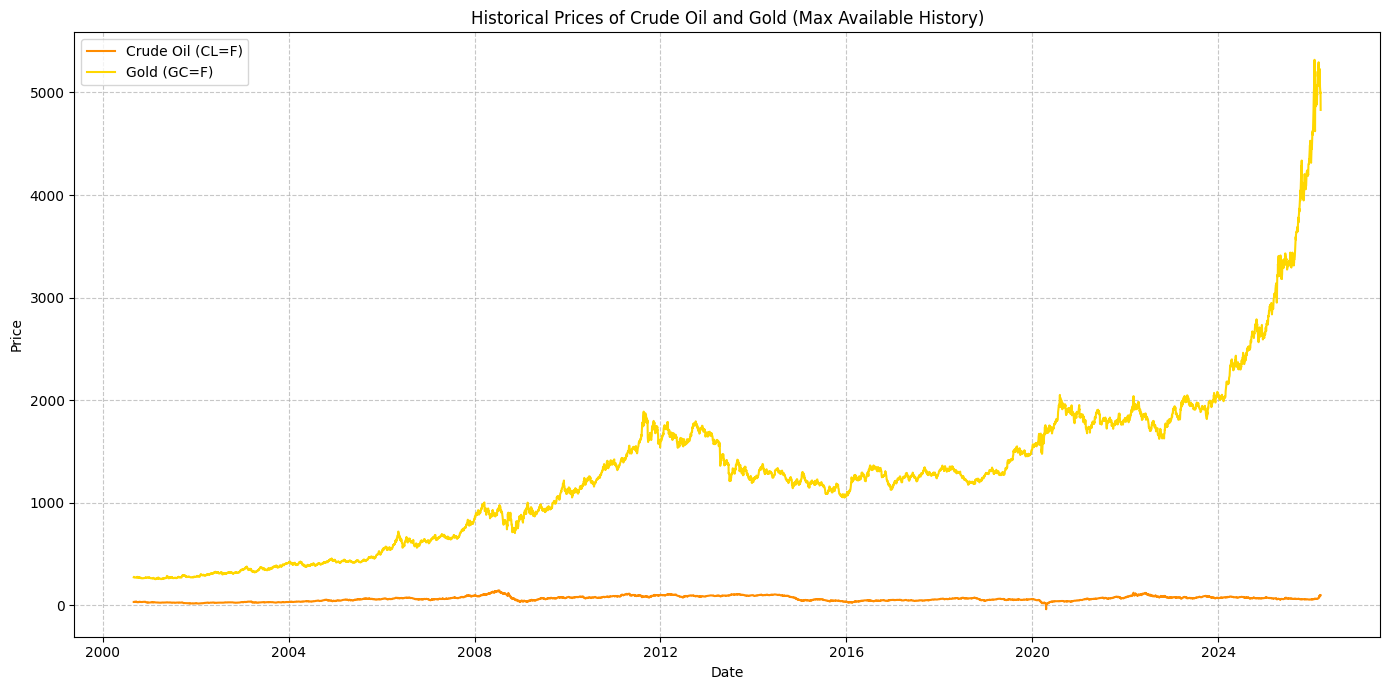

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(combined_data.index, combined_data[f'{oil_ticker}_Close'], label='Crude Oil (CL=F)', color='darkorange')
plt.plot(combined_data.index, combined_data[f'{gold_ticker}_Close'], label='Gold (GC=F)', color='gold')

plt.title('Historical Prices of Crude Oil and Gold (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We can also analyze the correlation between Oil and Gold prices to understand their relationship.

Correlation Matrix of Daily Percentage Changes (Max Available History):


,Price,CL=F_Close,GC=F_Close
,Ticker,CL=F,GC=F
Price,Ticker,,
CL=F_Close,CL=F,1.000000,0.096556
GC=F_Close,GC=F,0.096556,1.000000


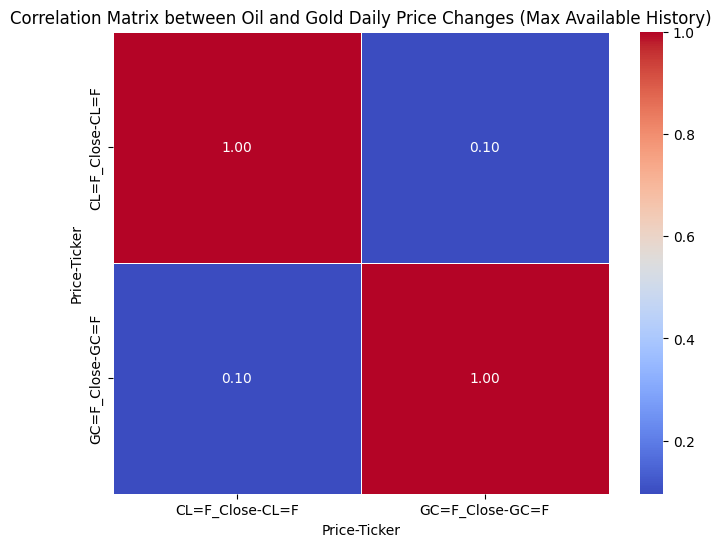

In [ ]:
# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Calculate the correlation matrix
correlation_matrix = price_changes.corr()

print("Correlation Matrix of Daily Percentage Changes (Max Available History):")
display(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix between Oil and Gold Daily Price Changes (Max Available History)')
plt.show()

### 3. Lead-Lag and Causality Analysis: Granger Causality Test

The Granger Causality test is a statistical hypothesis test for determining whether one time series is useful in forecasting another. A time series X is said to Granger-cause Y if predictions of Y based on its own past values and the past values of X are better than predictions of Y based only on Y's own past values.

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare the data for Granger Causality Test
# The test requires a DataFrame with the two series.
# Let's use the price_changes DataFrame.
# Ensure the DataFrame is clean and contains only the two series for the test.

df_granger = price_changes[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']].copy()

print(f"\n--- Granger Causality Test: Does {oil_ticker} (Oil) Granger-Cause {gold_ticker} (Gold)? ---")
# Test if Oil Granger-causes Gold
# maxlag can be adjusted; 5 for 5 trading days (1 week), 20 for 1 month
granger_results_oil_gold = grangercausalitytests(df_granger[[f'{gold_ticker}_Close', f'{oil_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_oil_gold[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_oil_gold[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 20 (p-value >= 0.05).")


print(f"\n--- Granger Causality Test: Does {gold_ticker} (Gold) Granger-Cause {oil_ticker} (Oil)? ---")
# Test if Gold Granger-causes Oil
granger_results_gold_oil = grangercausalitytests(df_granger[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_gold_oil[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_gold_oil[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 20 (p-value >= 0.05).")


--- Granger Causality Test: Does CL=F (Oil) Granger-Cause GC=F (Gold)? ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(



Results for lag 5:
  ssr_ftest p-value: 0.0675
  ssr_chi2test p-value: 0.0669
  lrtest p-value: 0.0671
  params_ftest p-value: 0.0675
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 5 (p-value >= 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.1243
  ssr_chi2test p-value: 0.1192
  lrtest p-value: 0.1207
  params_ftest p-value: 0.1243
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 20 (p-value >= 0.05).

--- Granger Causality Test: Does GC=F (Gold) Granger-Cause CL=F (Oil)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0318
  ssr_chi2test p-value: 0.0314
  lrtest p-value: 0.0315
  params_ftest p-value: 0.0318
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 5 (p-value < 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.0000
  ssr_chi2test p-value: 0.0000
  lrtest p-value: 0.0000
  params_ftest p-value: 0.0000
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 20 (p-value < 0.05).


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### 5. Stationarity and Cointegration Tests: Cointegration Test

While the Augmented Dickey-Fuller (ADF) test checked for stationarity of individual series (daily percentage changes), a cointegration test checks for a long-term, stable relationship between two *non-stationary* time series. If two series are cointegrated, it means they tend to move together over the long run, even if they wander independently in the short term. For this test, we typically use the original price series, which are usually non-stationary.

In [ ]:
from statsmodels.tsa.stattools import coint

print("\n--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---")

# Perform the Engle-Granger two-step cointegration test on the original price series
# The coint function returns: (t-statistic, p-value, critical_values)

# Ensure both series are aligned and have the same length
# We'll use the combined_data which contains the original prices
series1_prices = combined_data[f'{oil_ticker}_Close']
series2_prices = combined_data[f'{gold_ticker}_Close']

coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

print(f'Test Statistic: {coint_t:.3f}')
print(f'p-value: {coint_p_value:.3f}')
print('Critical Values:')
# Critical values are typically returned as an array [1% critical value, 5% critical value, 10% critical value]
print(f'\t1%: {coint_critical_values[0]:.3f}')
print(f'\t5%: {coint_critical_values[1]:.3f}')
print(f'\t10%: {coint_critical_values[2]:.3f}')

if coint_p_value < 0.05:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely cointegrated (p-value < 0.05).")
    print("This suggests a long-term equilibrium relationship between them.")
else:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely NOT cointegrated (p-value >= 0.05).")
    print("This suggests no long-term equilibrium relationship.")


--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---
Test Statistic: -3.157
p-value: 0.077
Critical Values:
	1%: -3.898
	5%: -3.337
	10%: -3.045
Conclusion: The price series of CL=F and GC=F are likely NOT cointegrated (p-value >= 0.05).
This suggests no long-term equilibrium relationship.


### 3. Lead-Lag and Causality Analysis: Granger Causality Test

The Granger Causality test is a statistical hypothesis test for determining whether one time series is useful in forecasting another. A time series X is said to Granger-cause Y if predictions of Y based on its own past values and the past values of X are better than predictions of Y based only on Y's own past values.

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare the data for Granger Causality Test
# The test requires a DataFrame with the two series.
# Let's use the price_changes DataFrame.
# Ensure the DataFrame is clean and contains only the two series for the test.

df_granger = price_changes[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']].copy()

print(f"\n--- Granger Causality Test: Does {oil_ticker} (Oil) Granger-Cause {gold_ticker} (Gold)? ---")
# Test if Oil Granger-causes Gold
# maxlag can be adjusted; 5 for 5 trading days (1 week), 20 for 1 month
granger_results_oil_gold = grangercausalitytests(df_granger[[f'{gold_ticker}_Close', f'{oil_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_oil_gold[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_oil_gold[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 20 (p-value >= 0.05).")


print(f"\n--- Granger Causality Test: Does {gold_ticker} (Gold) Granger-Cause {oil_ticker} (Oil)? ---")
# Test if Gold Granger-causes Oil
granger_results_gold_oil = grangercausalitytests(df_granger[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_gold_oil[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_gold_oil[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 20 (p-value >= 0.05).")


--- Granger Causality Test: Does CL=F (Oil) Granger-Cause GC=F (Gold)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0675
  ssr_chi2test p-value: 0.0669
  lrtest p-value: 0.0671
  params_ftest p-value: 0.0675
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 5 (p-value >= 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.1243
  ssr_chi2test p-value: 0.1192
  lrtest p-value: 0.1207
  params_ftest p-value: 0.1243
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 20 (p-value >= 0.05).

--- Granger Causality Test: Does GC=F (Gold) Granger-Cause CL=F (Oil)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0318
  ssr_chi2test p-value: 0.0314
  lrtest p-value: 0.0315
  params_ftest p-value: 0.0318
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 5 (p-value < 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.0000
  ssr_chi2test p-value: 0.0000
  lrtest p-value: 0.0000
  params_ftest p-value: 0.0000
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 20 (p-value < 0.05).


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### 5. Stationarity and Cointegration Tests: Cointegration Test

While the Augmented Dickey-Fuller (ADF) test checked for stationarity of individual series (daily percentage changes), a cointegration test checks for a long-term, stable relationship between two *non-stationary* time series. If two series are cointegrated, it means they tend to move together over the long run, even if they wander independently in the short term. For this test, we typically use the original price series, which are usually non-stationary.

In [ ]:
from statsmodels.tsa.stattools import coint

print("\n--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---")

# Perform the Engle-Granger two-step cointegration test on the original price series
# The coint function returns: (t-statistic, p-value, critical_values)

# Ensure both series are aligned and have the same length
# We'll use the combined_data which contains the original prices
series1_prices = combined_data[f'{oil_ticker}_Close']
series2_prices = combined_data[f'{gold_ticker}_Close']

coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

print(f'Test Statistic: {coint_t:.3f}')
print(f'p-value: {coint_p_value:.3f}')
print('Critical Values:')
# Critical values are typically returned as an array [1% critical value, 5% critical value, 10% critical value]
print(f'\t1%: {coint_critical_values[0]:.3f}')
print(f'\t5%: {coint_critical_values[1]:.3f}')
print(f'\t10%: {coint_critical_values[2]:.3f}')

if coint_p_value < 0.05:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely cointegrated (p-value < 0.05).")
    print("This suggests a long-term equilibrium relationship between them.")
else:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely NOT cointegrated (p-value >= 0.05).")
    print("This suggests no long-term equilibrium relationship.")


--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---
Test Statistic: -3.157
p-value: 0.077
Critical Values:
	1%: -3.898
	5%: -3.337
	10%: -3.045
Conclusion: The price series of CL=F and GC=F are likely NOT cointegrated (p-value >= 0.05).
This suggests no long-term equilibrium relationship.


### 1. Rolling Volatility Analysis

Volatility is a key measure of risk. By calculating the rolling standard deviation of daily percentage changes, we can observe how the risk profile of Oil and Gold has evolved over time.

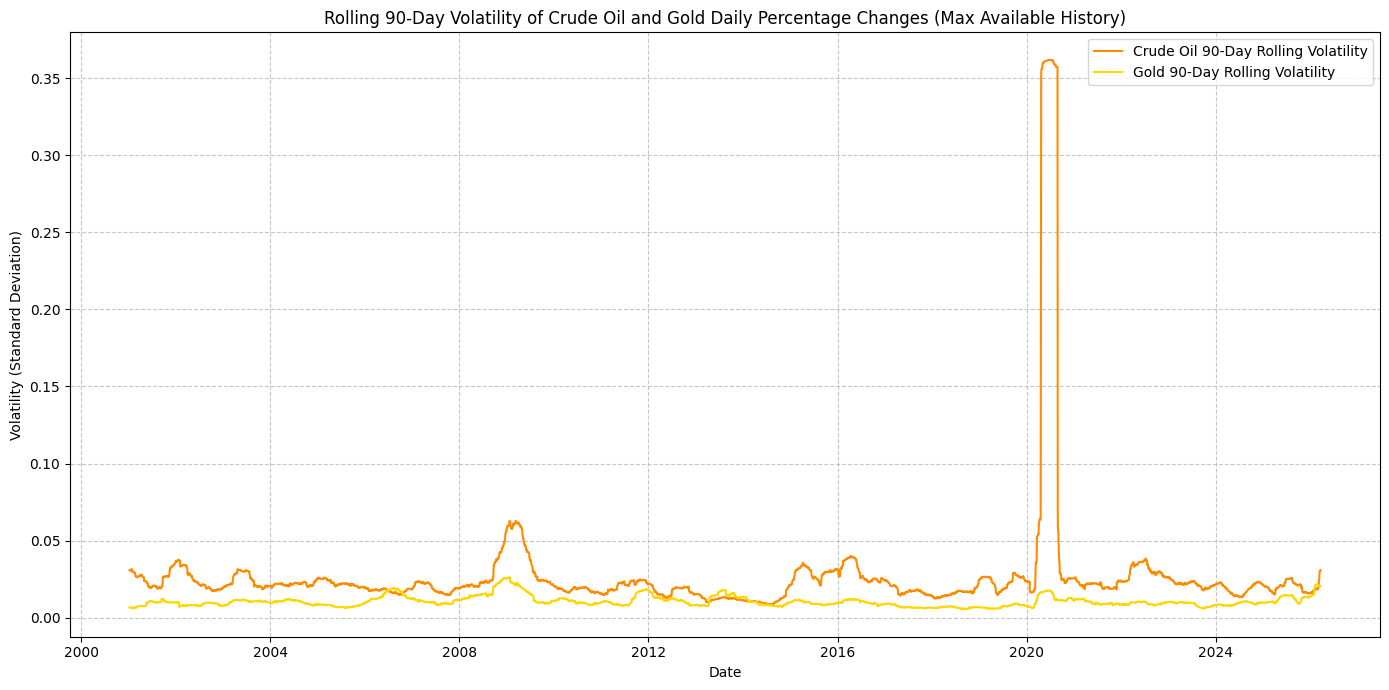

Displaying last few values of 90-day Rolling Volatility for Oil:


Ticker,CL=F
Date,
2026-03-12,0.030069
2026-03-13,0.030190
2026-03-16,0.030812
2026-03-17,0.030881
2026-03-18,0.030864


Displaying last few values of 90-day Rolling Volatility for Gold:


Ticker,GC=F
Date,
2026-03-12,0.020313
2026-03-13,0.020361
2026-03-16,0.020417
2026-03-17,0.020348
2026-03-18,0.020710


In [ ]:
# Define a window for rolling volatility (e.g., 90 days)
volatility_window = 90

# Calculate the rolling standard deviation of daily percentage changes
oil_volatility = price_changes[f'{oil_ticker}_Close'].rolling(window=volatility_window).std()
gold_volatility = price_changes[f'{gold_ticker}_Close'].rolling(window=volatility_window).std()

# Plotting the rolling volatility
plt.figure(figsize=(14, 7))
plt.plot(oil_volatility.index, oil_volatility, label=f'Crude Oil {volatility_window}-Day Rolling Volatility', color='darkorange')
plt.plot(gold_volatility.index, gold_volatility, label=f'Gold {volatility_window}-Day Rolling Volatility', color='gold')

plt.title(f'Rolling {volatility_window}-Day Volatility of Crude Oil and Gold Daily Percentage Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few values of {volatility_window}-day Rolling Volatility for Oil:")
display(oil_volatility.tail())
print(f"Displaying last few values of {volatility_window}-day Rolling Volatility for Gold:")
display(gold_volatility.tail())

### 2. Relative Performance and Ratio Analysis

Understanding the relative performance and the ratio between Oil and Gold can reveal insights into their economic relationship and investor sentiment. A rising Oil/Gold ratio might suggest economic expansion, while a falling ratio could indicate economic stress or a flight to safety (gold).

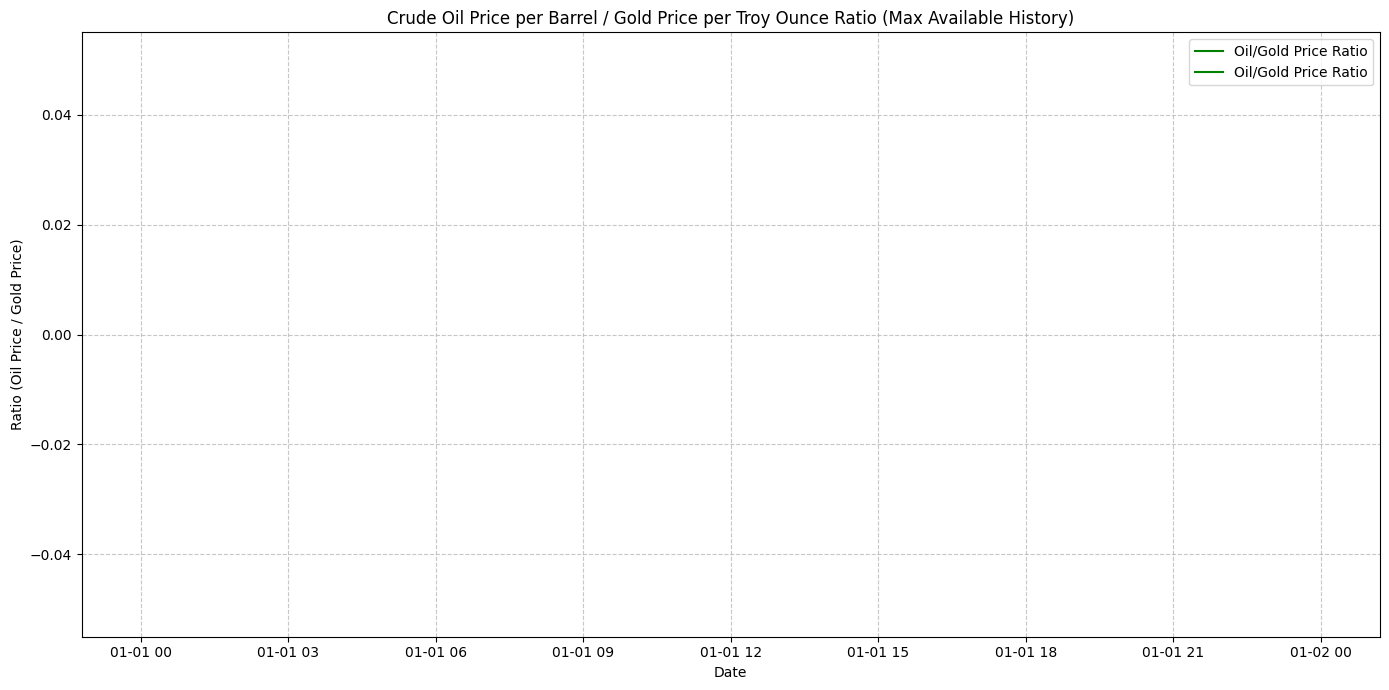

Displaying last few values of Oil/Gold Ratio:


Ticker,CL=F,GC=F
Date,,
2026-03-12,NaN,NaN
2026-03-13,NaN,NaN
2026-03-16,NaN,NaN
2026-03-17,NaN,NaN
2026-03-18,NaN,NaN


In [ ]:
# Calculate the Oil/Gold price ratio
oil_gold_ratio = combined_data[f'{oil_ticker}_Close'] / combined_data[f'{gold_ticker}_Close']

# Plotting the Oil/Gold Ratio
plt.figure(figsize=(14, 7))
plt.plot(oil_gold_ratio.index, oil_gold_ratio, label='Oil/Gold Price Ratio', color='green')

plt.title('Crude Oil Price per Barrel / Gold Price per Troy Ounce Ratio (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Ratio (Oil Price / Gold Price)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Displaying last few values of Oil/Gold Ratio:")
display(oil_gold_ratio.tail())

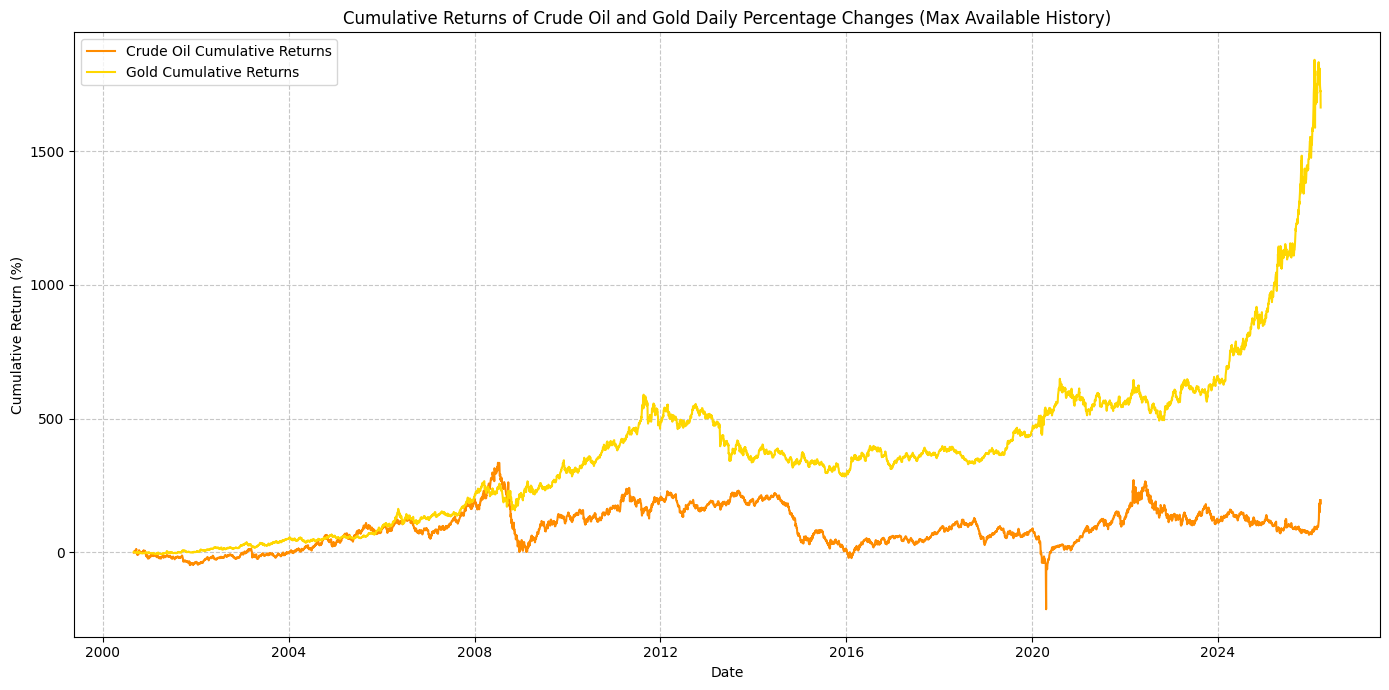

Displaying last few values of Cumulative Returns for Oil:


Ticker,CL=F
Date,
2026-03-12,1.866168
2026-03-13,1.955389
2026-03-16,1.799401
2026-03-17,1.880539
2026-03-18,1.953593


Displaying last few values of Cumulative Returns for Gold:


Ticker,GC=F
Date,
2026-03-12,17.677619
2026-03-13,17.446514
2026-03-16,17.232932
2026-03-17,17.258489
2026-03-18,16.633808


In [ ]:
# Calculate cumulative returns for both assets
# We'll use the price_changes DataFrame which already contains daily percentage changes
cumulative_returns_oil = (1 + price_changes[f'{oil_ticker}_Close']).cumprod() - 1
cumulative_returns_gold = (1 + price_changes[f'{gold_ticker}_Close']).cumprod() - 1

# Plotting cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(cumulative_returns_oil.index, cumulative_returns_oil * 100, label=f'Crude Oil Cumulative Returns', color='darkorange')
plt.plot(cumulative_returns_gold.index, cumulative_returns_gold * 100, label=f'Gold Cumulative Returns', color='gold')

plt.title('Cumulative Returns of Crude Oil and Gold Daily Percentage Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Displaying last few values of Cumulative Returns for Oil:")
display(cumulative_returns_oil.tail())
print("Displaying last few values of Cumulative Returns for Gold:")
display(cumulative_returns_gold.tail())

### 3. Stationarity Tests (Augmented Dickey-Fuller Test)

Stationarity is a fundamental property for many time series models. A stationary series has statistical properties (mean, variance, autocorrelation) that do not change over time. We will use the Augmented Dickey-Fuller (ADF) test to check for stationarity in the daily percentage changes of Oil and Gold.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on Oil daily percentage changes
print(f"\n--- Augmented Dickey-Fuller Test for {oil_ticker} Daily Percentage Changes ---")
adf_oil = adfuller(price_changes[f'{oil_ticker}_Close'].dropna())
print('ADF Statistic: %f' % adf_oil[0])
print('p-value: %f' % adf_oil[1])
print('Critical Values:')
for key, value in adf_oil[4].items():
    print('\t%s: %.3f' % (key, value))

if adf_oil[1] <= 0.05:
    print("Result: The series is likely stationary (p-value <= 0.05).")
else:
    print("Result: The series is likely non-stationary (p-value > 0.05).")

# Perform ADF test on Gold daily percentage changes
print(f"\n--- Augmented Dickey-Fuller Test for {gold_ticker} Daily Percentage Changes ---")
adf_gold = adfuller(price_changes[f'{gold_ticker}_Close'].dropna())
print('ADF Statistic: %f' % adf_gold[0])
print('p-value: %f' % adf_gold[1])
print('Critical Values:')
for key, value in adf_gold[4].items():
    print('\t%s: %.3f' % (key, value))

if adf_gold[1] <= 0.05:
    print("Result: The series is likely stationary (p-value <= 0.05).")
else:
    print("Result: The series is likely non-stationary (p-value > 0.05).")


--- Augmented Dickey-Fuller Test for CL=F Daily Percentage Changes ---
ADF Statistic: -14.767415
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The series is likely stationary (p-value <= 0.05).

--- Augmented Dickey-Fuller Test for GC=F Daily Percentage Changes ---
ADF Statistic: -25.385216
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The series is likely stationary (p-value <= 0.05).


### 3. Lead-Lag and Causality Analysis: Cross-Correlation Function (CCF)

The Cross-Correlation Function (CCF) helps us understand if the price changes of one asset tend to lead or lag the price changes of another asset. A positive correlation at a positive lag `k` means that the first series' values tend to be correlated with the second series' values `k` periods *later*. Conversely, a negative lag `k` means the first series tends to be correlated with the second series `k` periods *earlier*.

/tmp/ipykernel_677/754547597.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/754547597.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


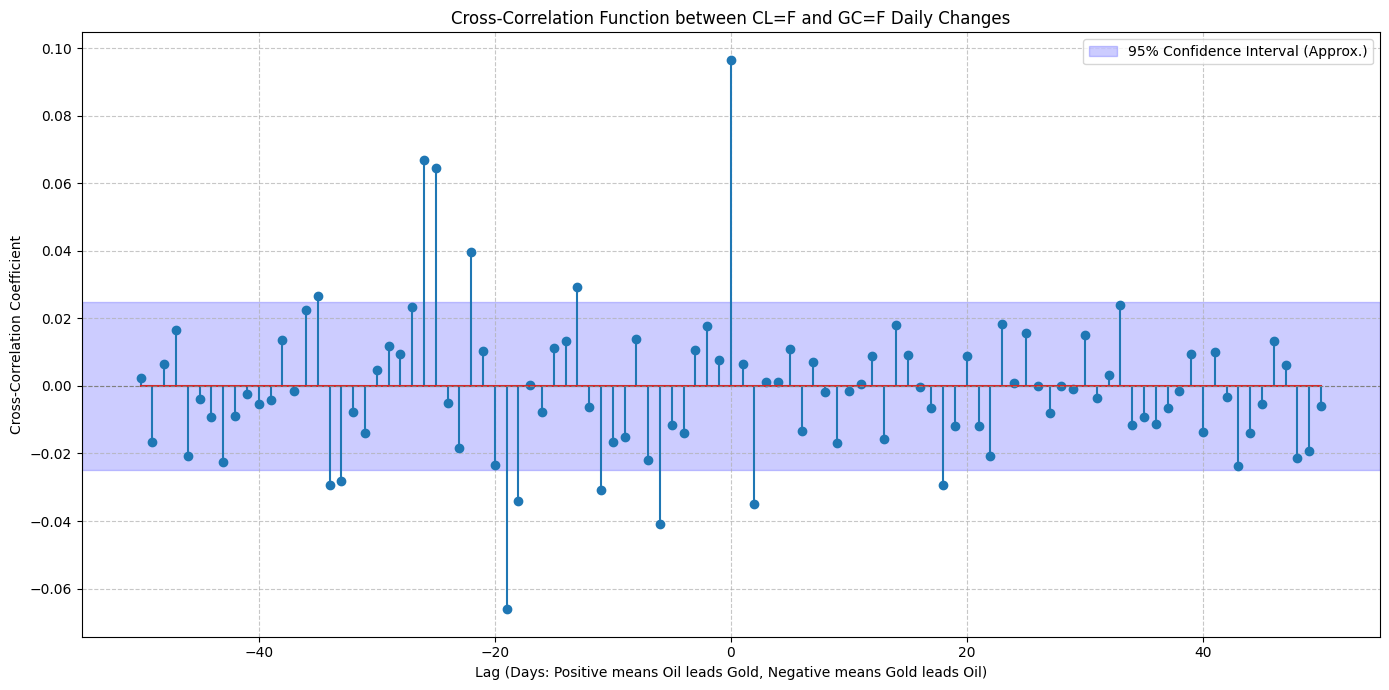

Displaying Cross-Correlation values for selected lags:


,Lag,Correlation
15,-35,0.026680
16,-34,-0.029334
17,-33,-0.028183
24,-26,0.066755
25,-25,0.064439
28,-22,0.039579
31,-19,-0.066105
32,-18,-0.034044
37,-13,0.029338
39,-11,-0.030777


In [12]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf
import numpy as np

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Calculate Cross-Correlation Function for Oil leading Gold
# Lags from -50 to 50 (50 days Oil leads Gold, 50 days Gold leads Oil)

lags = range(-50, 51) # 50 days before to 50 days after
ccf_values = []

# price_changes already calculated: oil_ticker_Close, gold_ticker_Close
series1 = price_changes['Oil_Close']
series2 = price_changes['Gold_Close']

# Combine for symmetrical plot (adjusting lags)
# Let's create a combined CCF with negative and positive lags centered at 0
max_lags = 50
lags_range = range(-max_lags, max_lags + 1)

# Calculate cross-correlation for different lags
cross_correlations = []
for lag in lags_range:
    # Get the relevant numpy arrays, aligning them
    s1_aligned = series1.values
    s2_shifted = series2.shift(-lag)
    s2_shifted_aligned = s2_shifted.values

    # Remove NaNs from both arrays simultaneously for correlation calculation
    valid_indices = ~np.isnan(s1_aligned) & ~np.isnan(s2_shifted_aligned)
    s1_clean = s1_aligned[valid_indices]
    s2_clean = s2_shifted_aligned[valid_indices]

    if len(s1_clean) > 1: # Need at least 2 points for correlation
        corr = np.corrcoef(s1_clean, s2_clean)[0, 1]
    else:
        corr = np.nan # Not enough data to compute correlation

    cross_correlations.append(corr)

# Plotting the Cross-Correlation Function
plt.figure(figsize=(14, 7))
plt.stem(lags_range, cross_correlations)
plt.title(f'Cross-Correlation Function between {oil_ticker} and {gold_ticker} Daily Changes')
plt.xlabel('Lag (Days: Positive means Oil leads Gold, Negative means Gold leads Oil)')
plt.ylabel('Cross-Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
# Add confidence intervals for visual reference (approximate for cross-correlation)
# An approximate confidence interval can be calculated as +/- 2/sqrt(N)
N = len(price_changes) # Number of observations
conf_int = 2 / (N**0.5)
plt.axhspan(-conf_int, conf_int, alpha=0.2, color='blue', label='95% Confidence Interval (Approx.)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Displaying Cross-Correlation values for selected lags:")
cross_corr_df = pd.DataFrame({'Lag': lags_range, 'Correlation': cross_correlations})
display(cross_corr_df[(cross_corr_df['Correlation'].abs() > conf_int).fillna(False)])

### 4. Event Study Analysis: Impact of Global Events

Event study analysis examines the behavior of asset prices around a specific event. We'll pick a few significant historical dates and visualize the price movements of Oil and Gold in the period surrounding these events to see their typical reactions.

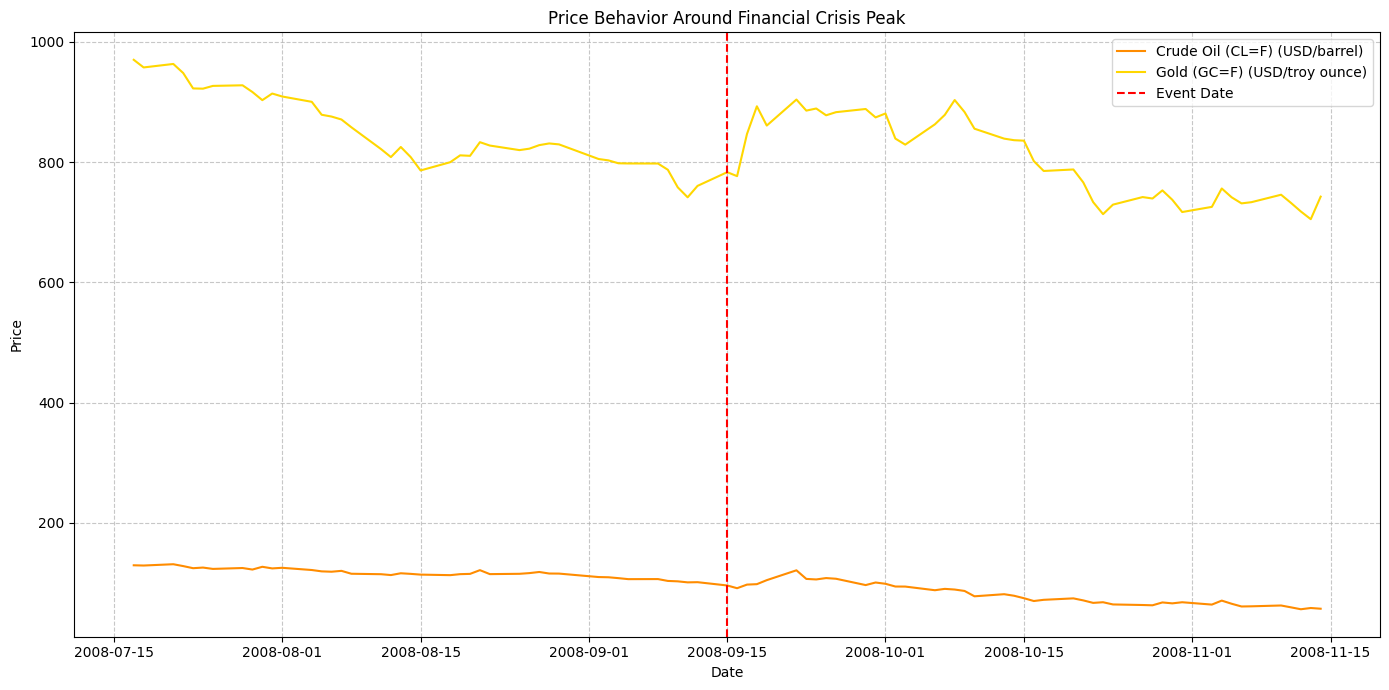

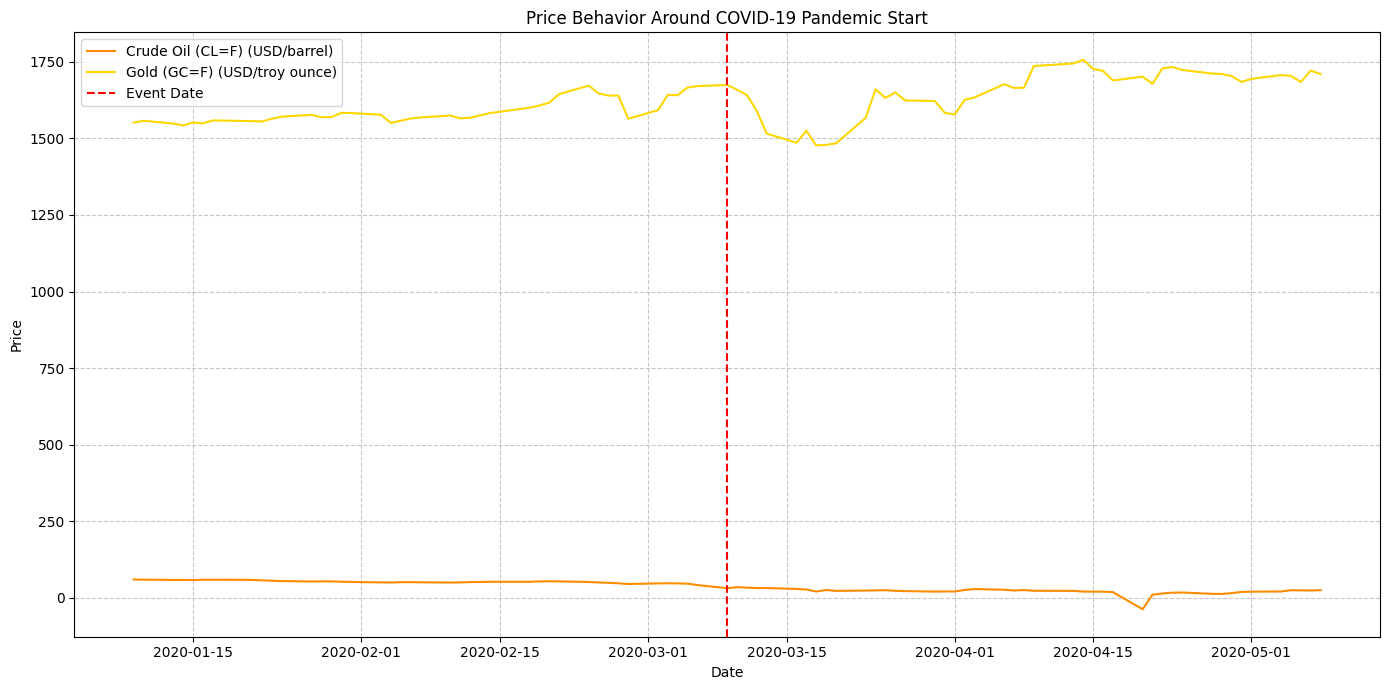

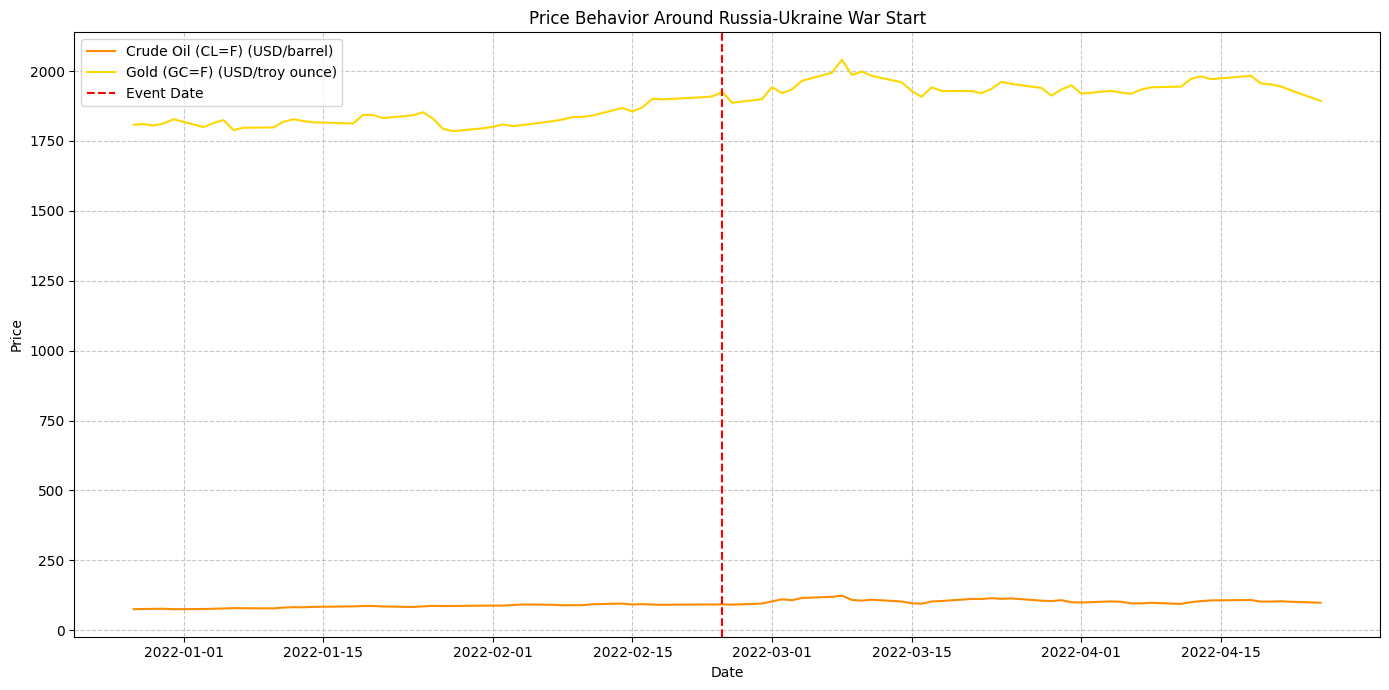

No data available for event 'Dot-com Bubble Burst' in the specified window.


In [ ]:
# Define a few significant global events
# Format: {'Event Name': 'YYYY-MM-DD'}
events = {
    'Financial Crisis Peak': '2008-09-15', # Lehman Brothers collapse
    'COVID-19 Pandemic Start': '2020-03-09', # Market crash due to COVID-19 fears
    'Russia-Ukraine War Start': '2022-02-24', # Invasion of Ukraine
    'Dot-com Bubble Burst': '2000-03-10' # Approx. start of dot-com bubble burst
}

# Define the window around each event (e.g., +/- 60 days)
window_days = 60

for event_name, event_date_str in events.items():
    event_date = pd.to_datetime(event_date_str)

    start_date = event_date - pd.Timedelta(days=window_days)
    end_date = event_date + pd.Timedelta(days=window_days)

    # Filter data for the event window
    event_data = combined_data.loc[start_date:end_date]

    if not event_data.empty:
        plt.figure(figsize=(14, 7))

        plt.plot(event_data.index, event_data[f'{oil_ticker}_Close'], label=f'Crude Oil (CL=F) (USD/barrel)', color='darkorange')
        plt.plot(event_data.index, event_data[f'{gold_ticker}_Close'], label=f'Gold (GC=F) (USD/troy ounce)', color='gold')

        plt.axvline(event_date, color='red', linestyle='--', label='Event Date')

        plt.title(f'Price Behavior Around {event_name}')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data available for event '{event_name}' in the specified window.")

### Autocorrelation of Oil and Gold Daily Percentage Changes

Autocorrelation measures the correlation of a time series with a lagged version of itself. It helps identify patterns such as trend, seasonality, or other non-random behaviors in the data. For financial time series like daily returns, we often look for the absence of significant autocorrelation, which suggests that returns are random and thus unpredictable from their own past values.

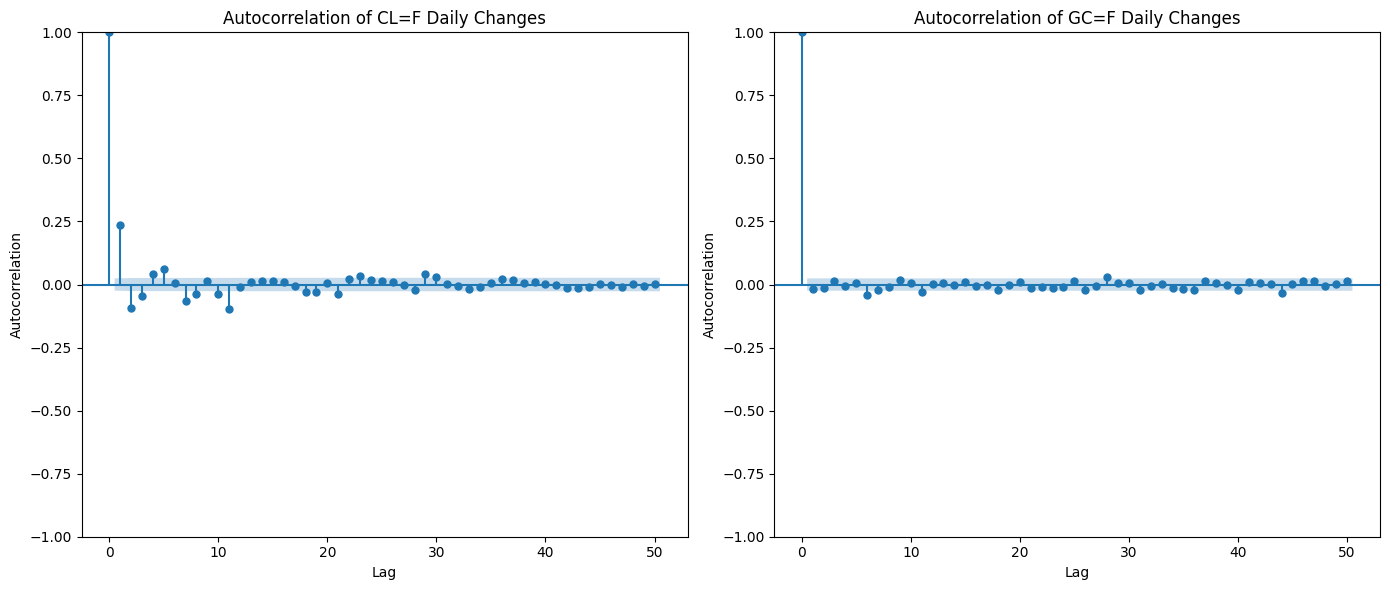

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF) for Oil daily percentage changes
plt.figure(figsize=(14, 6))
plot_acf(price_changes[f'{oil_ticker}_Close'], lags=50, ax=plt.subplot(121), title=f'Autocorrelation of {oil_ticker} Daily Changes')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

# Plot Autocorrelation Function (ACF) for Gold daily percentage changes
plot_acf(price_changes[f'{gold_ticker}_Close'], lags=50, ax=plt.subplot(122), title=f'Autocorrelation of {gold_ticker} Daily Changes')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

### Interpretation of Autocorrelation Plots

*   **Y-axis**: Represents the autocorrelation coefficient (ranging from -1 to 1).
*   **X-axis**: Represents the lag, which is the number of time periods (days in this case) between the observation and the lagged observation.
*   **Blue Shaded Area**: This represents the confidence interval. Any autocorrelation values falling within this area are generally considered not statistically significant at a 95% confidence level.

For financial asset returns, we typically expect to see very little significant autocorrelation beyond lag 0. This is because if there were strong predictable patterns (high autocorrelation), they would likely be arbitraged away by market participants. If a bar extends significantly outside the blue area, it suggests that past returns (at that specific lag) have a statistically significant correlation with current returns.